In [3]:
order=['host_109480',
'host_59474',
'host_258959',
'host_105273',
'host_105295',
'host_59473',
'host_294653',
'host_258863',
'host_9433',
'host_59476',
'host_94956',
'host_9400',
'host_58060',
'host_77214',
'host_9402',
'host_196297',
'host_58065',
'host_58083',
'host_9408',
'host_9407',
'host_124756',
'host_188568',
'host_186990',
'host_188569',
'host_77218',
'host_59479',
'host_519037',
'host_342862',
'host_188571',
'host_59477',
'host_89399',
'host_476589',
'host_196889',
'host_188572',
'host_196296',
'host_169756',
'host_159858']

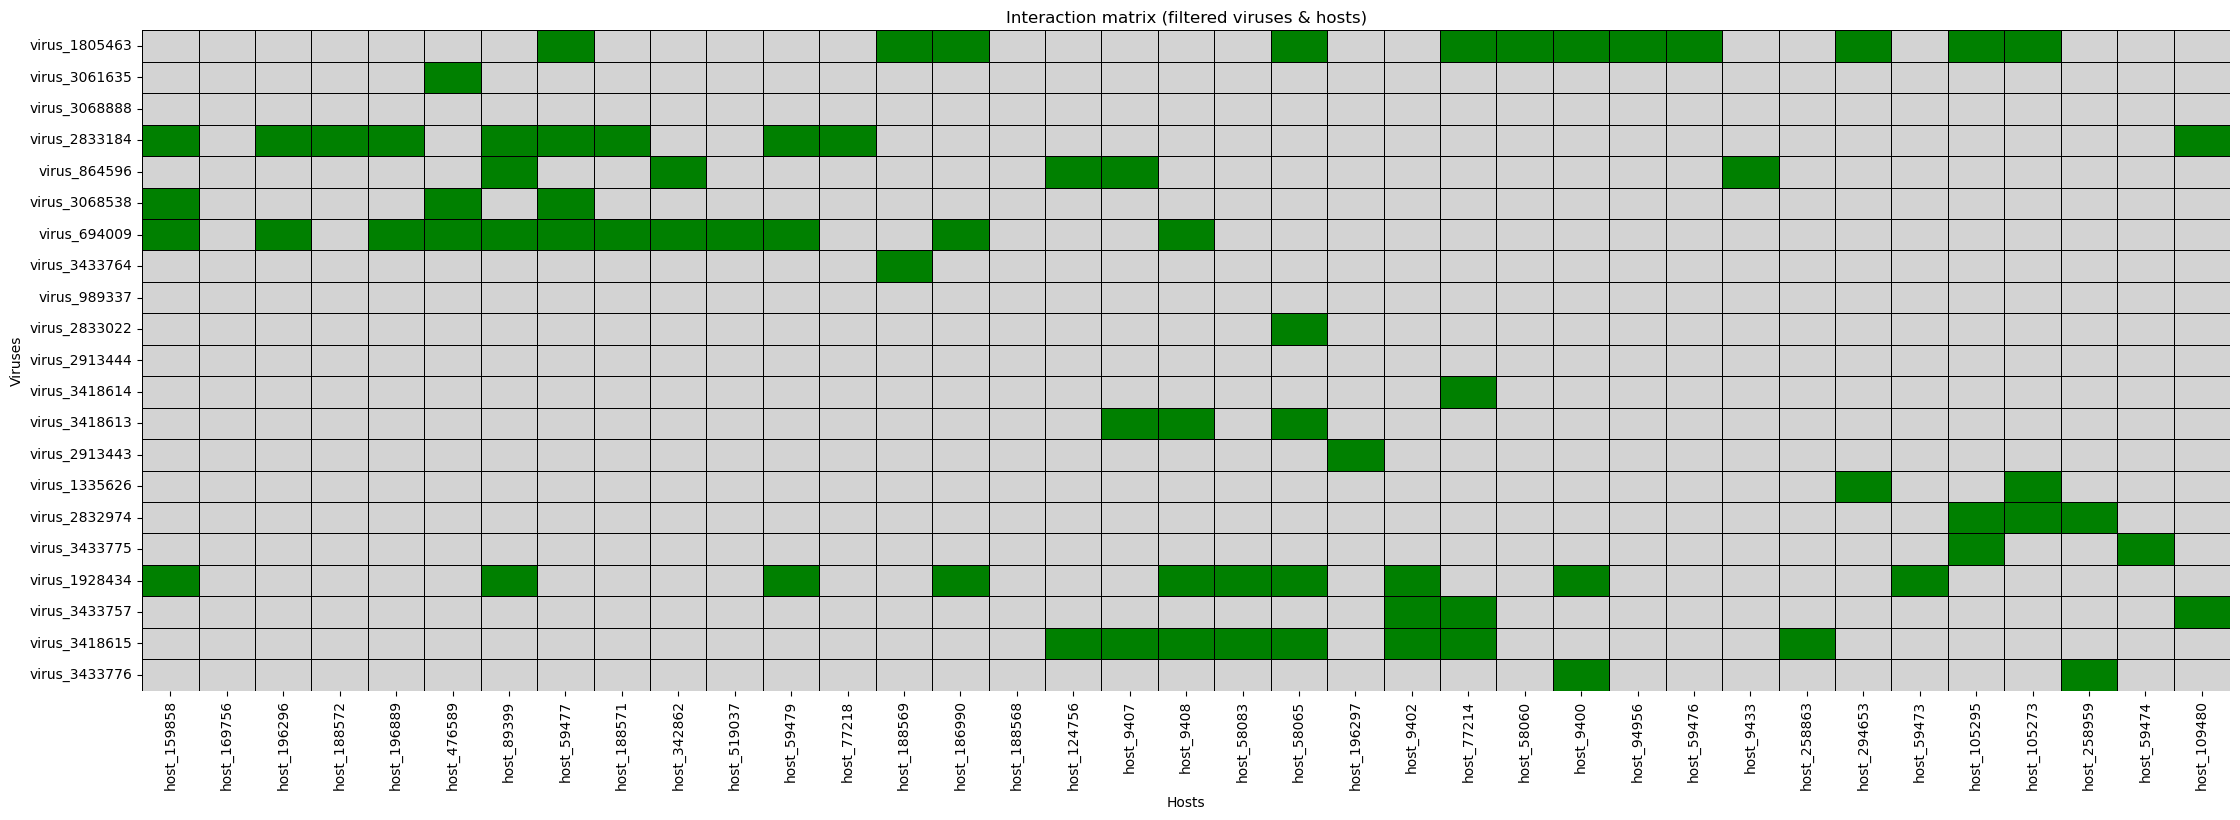

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Paths
interaction_full_csv = "../interaction_matrix_tree_leaves_beta_only.csv"
order_csv = "../flipped_matrix_reordered_del_dup.csv"

# Load full interaction matrix
df_full = pd.read_csv(interaction_full_csv, index_col=0)

# Load virus order
df_order = pd.read_csv(order_csv, index_col=0)
virus_order = df_order.index.tolist()  # virus order in tree leaves CSV

# Filter viruses in the desired order
df_filtered = df_full.loc[df_full.index.isin(virus_order)]
df_filtered = df_filtered.loc[virus_order]  # reorder rows exactly

# Keep only target hosts
tp_hosts = ['host_77214', 'host_188572', 'host_169756', 'host_59473', 'host_109480', 'host_9407', 'host_519037', 'host_58065', 'host_9402', 'host_58083', 'host_105295', 'host_9400', 'host_89399', 'host_77218', 'host_196297', 'host_188571', 'host_196296', 'host_196889', 'host_59479', 'host_94956', 'host_258959', 'host_258863', 'host_342862', 'host_9408', 'host_59476', 'host_105273', 'host_59474', 'host_9433', 'host_294653', 'host_186990', 'host_476589', 'host_58060', 'host_188568', 'host_124756', 'host_188569', 'host_159858', 'host_59477']  # example
df_filtered = df_filtered[order]  # reorder columns exactly


# Plot heatmap: 1 = green, 0 = grey
cmap = sns.color_palette(["lightgrey", "green"])  # 0 = grey, 1 = green

plt.figure(figsize=(len(tp_hosts)*0.5+4, len(df_filtered)*0.3+2))
sns.heatmap(df_filtered, cmap=cmap, cbar=False, linewidths=0.5, linecolor='black', square=False)
plt.xlabel("Hosts")
plt.ylabel("Viruses")
plt.title("Interaction matrix (filtered viruses & hosts)")
plt.tight_layout()
plt.savefig("interaction_matrix_filtered_heatmap.png", dpi=300)


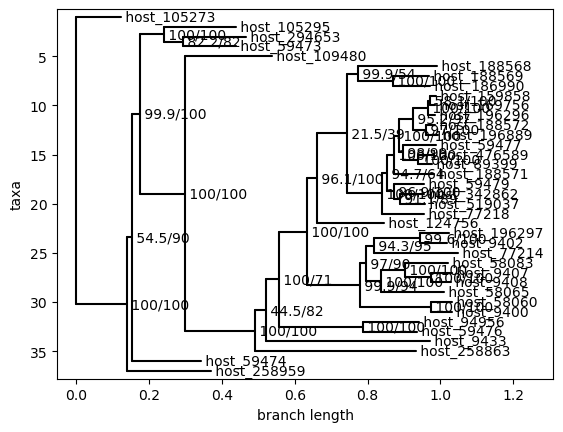

In [2]:
from Bio import Phylo

# Load your Newick tree
tree_file = "../virion_bat_cov_output/trees/hosts_tree.newick"
tree = Phylo.read(tree_file, "newick")


# Function to prune the tree
def prune_tree(tree, keep_leaves):
    # Find all terminals (leaves) to remove
    to_remove = [term for term in tree.get_terminals() if term.name not in keep_leaves]
    for leaf in to_remove:
        tree.prune(leaf)
    return tree

# Prune the tree
pruned_tree = prune_tree(tree, tp_hosts)

# Save pruned tree to a file
Phylo.write(pruned_tree, "pruned_tree_for_37_hosts.nwk", "newick")

# Optional: visualize
Phylo.draw(pruned_tree)  # requires matplotlib
